In [2]:
!pip install tensorflow
!pip install opencv-python
!pip install keras

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install numpy tensorflow matplotlib keras opencv-python


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Libraries used :

Numpy : Used for multidimensional arrays.

Matplotlib : Used to visualize data with graphs.

cv2 : OpenCV is used to deal with images.

Keras : It is the interface for Neural Networks and Tensorflow.

tensorflow: An open-source platform for machine learning and deep learning developed by Google

In [4]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
# ImageDataGenerator has moved to tf.keras.preprocessing.image
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from keras.preprocessing import image
from tensorflow.keras.optimizers import Adam
import cv2
from tensorflow.keras.preprocessing.image import img_to_array 

### Creating the train data generator


In [5]:
train_datagen = ImageDataGenerator(rescale = 1./255,
shear_range = 0.2,
zoom_range = 0.2,
horizontal_flip = True)

##### Training data which is present 

In [6]:
train_images = r"C:\Users\manya\OneDrive\Desktop\PneumoniaDetection\dataset\train"

Here every image is resized to (300,300)

In [7]:
train_generator = train_datagen.flow_from_directory(train_images,
    target_size = (300,300),
    batch_size = 128,
    class_mode = 'binary')

Found 687 images belonging to 2 classes.


Model outputs :

0 : Normal condition

1 : Pneumonia condition

In [8]:
train_generator.class_indices


{'NORMAL': 0, 'PNEUMONIA': 1}

##### Validation data generator and loading validation data

In [9]:
test_datagen = ImageDataGenerator(rescale = 1./255)
validation_generator = test_datagen.flow_from_directory(r"C:\Users\manya\OneDrive\Desktop\PneumoniaDetection\dataset\valid",
    target_size= (300,300),
    batch_size = 128,
    class_mode = 'binary')

Found 46 images belonging to 2 classes.


##### Plotting : Images with Pneumonia from dataset.

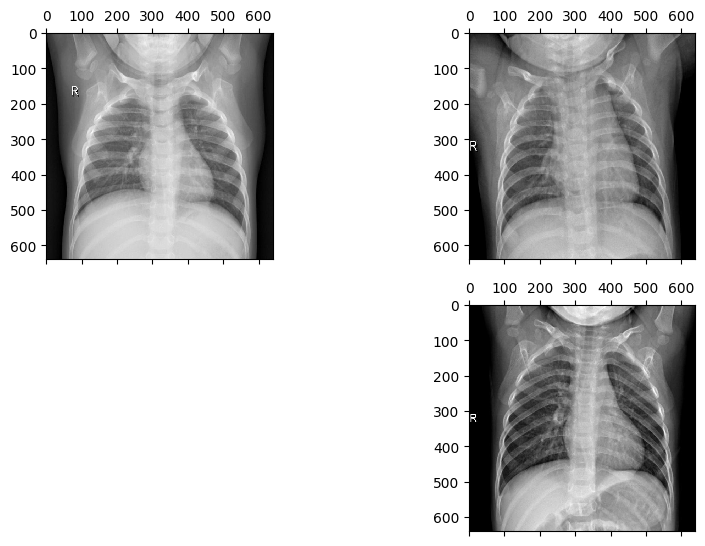

In [10]:
plot_image = plt.figure(figsize=(10,10))

plot1 = plot_image.add_subplot(3,2,1)
plot2 = plot_image.add_subplot(3,2,2)
plot4 = plot_image.add_subplot(3,2,4)
plot1.matshow(plt.imread(train_generator.filepaths[41]))
plot2.matshow(plt.imread(train_generator.filepaths[176]))
plot4.matshow(plt.imread(train_generator.filepaths[354]))



# Convolutional Neural Network


![alt text](image.png)

# Neural Networks using TensorFlow

In [11]:
model= tf.keras.models.Sequential([
                                   tf.keras.layers.Conv2D(16, (3,3), activation= 'relu', input_shape= (300, 300, 3)),
                                   tf.keras.layers.MaxPool2D(2,2),
                                   tf.keras.layers.Conv2D(32, (3,3), activation= 'relu'),
                                   tf.keras.layers.MaxPool2D(2,2),
                                   tf.keras.layers.Conv2D(64, (3,3), activation= 'relu'),
                                   tf.keras.layers.MaxPool2D(2,2),
                                   tf.keras.layers.Conv2D(128, (3,3), activation= 'relu'),
                                   tf.keras.layers.MaxPool2D(2,2),
                                   tf.keras.layers.Conv2D(128, (3,3), activation= 'relu'),
                                   tf.keras.layers.MaxPool2D(2,2),

                                   tf.keras.layers.Flatten(),
                                   tf.keras.layers.Dense(256, activation= 'relu'),
                                   tf.keras.layers.Dense(512, activation= 'relu'),
                                   tf.keras.layers.Dense(1, activation= 'sigmoid')
])
model.summary()
model.compile(optimizer= 'adam', loss= 'binary_crossentropy', metrics= ['accuracy'])

C:\Users\manya\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 298, 298, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 149, 149, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 147, 147, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 33, 33, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,983,009 (7.56 MB)

 Trainable params: 1,983,009 (7.56 MB)

 Non-trainable params: 0 (0.00 B)

### Training the model for 50 epochs

In [12]:
history = model.fit(train_generator, epochs = 50, validation_data = validation_generator)

C:\Users\manya\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.5539 - loss: 0.7066 - val_accuracy: 0.4783 - val_loss: 0.6929
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.6083 - loss: 0.6833 - val_accuracy: 0.4783 - val_loss: 0.7134
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 41s 7s/step - accuracy: 0.5954 - loss: 0.6684 - val_accuracy: 0.4783 - val_loss: 0.7110
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 42s 8s/step - accuracy: 0.5932 - loss: 0.6672 - val_accuracy: 0.4783 - val_loss: 0.6979
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 39s 6s/step - accuracy: 0.6028 - loss: 0.6445 - val_accuracy: 0.4783 - val_loss: 0.6542
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 39s 7s/step - accuracy: 0.5937 - loss: 0.6358 - val_accuracy: 0.4783 - val_loss: 0.6032
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 34s 6s/step - accuracy: 0.6209 - loss: 0.6095 - val_accuracy: 0.5435 - val_loss: 0.6833
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.6849 - loss: 0.5939 - val_accuracy: 0.6087 - val_loss: 0.5934
Epoch 9/

In [13]:
train_loss, train_accuracy = model.evaluate(train_generator, verbose=1)
val_loss, val_accuracy = model.evaluate(validation_generator, verbose=1)
print("Eval train acc:", train_accuracy, "Eval val acc:", val_accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9602 - loss: 0.0855
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.8696 - loss: 0.4064
Eval train acc: 0.960698664188385 Eval val acc: 0.8695651888847351


## Plotting Loss Vs Num. of Epochs

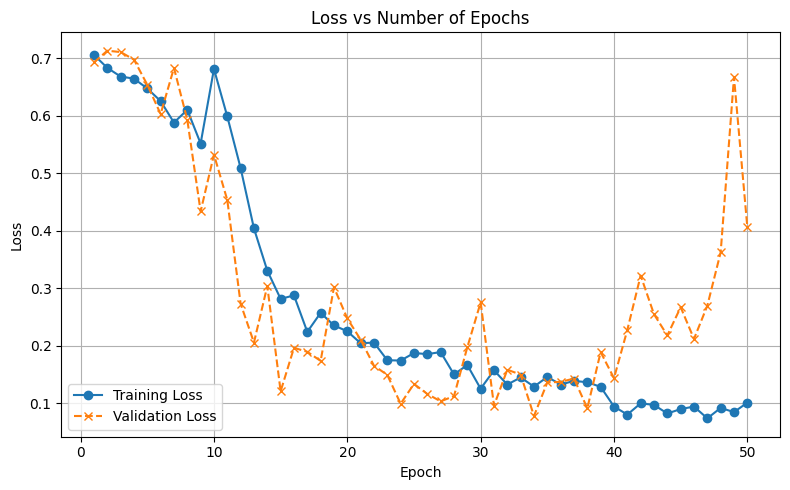

In [14]:
import matplotlib.pyplot as plt

# get history lists
train_loss = history.history.get("loss")
val_loss = history.history.get("val_loss")

if train_loss is None or val_loss is None:
    raise ValueError("history does not contain 'loss' or 'val_loss'. Confirm model.fit used validation_data/validation_split.")

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, "o-", label="Training Loss")
plt.plot(epochs, val_loss, "x--", label="Validation Loss")
plt.title("Loss vs Number of Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Saving the model

In [15]:
model.save("trained.h5")

#### Loading the saved model so that we can load the model which is already saved so lot of time can be saved and it can also be used for deployment.

In [16]:
from keras.models import load_model
model = load_model("trained.h5")

#### Loading the test data generator from drive

In [19]:
test_generator = test_datagen.flow_from_directory(r"C:\Users\manya\OneDrive\Desktop\PneumoniaDetection\dataset\test",
    target_size=(300,300),
    batch_size=128,
    class_mode='binary',
    shuffle=False)

Found 51 images belonging to 2 classes.


C:\Users\manya\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step
Confusion matrix:
 [[10  1]
 [10 30]]

Classification report:
               precision    recall  f1-score   support

      NORMAL       0.50      0.91      0.65        11
   PNEUMONIA       0.97      0.75      0.85        40

    accuracy                           0.78        51
   macro avg       0.73      0.83      0.75        51
weighted avg       0.87      0.78      0.80        51



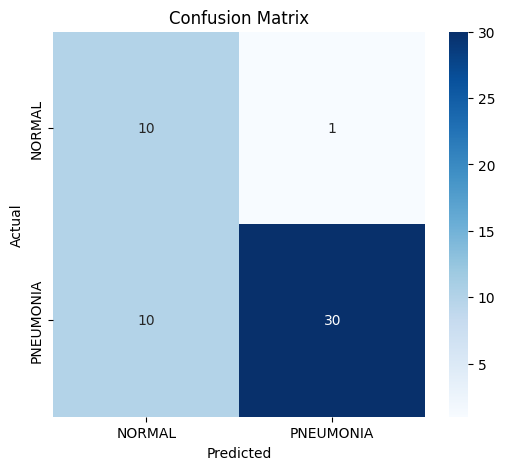

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns  # optional, for better matrix plot

# 1. Ensure generator is not shuffled
# test_generator = test_datagen.flow_from_directory(..., shuffle=False)

# 2. Predict
y_prob = model.predict(test_generator, verbose=1)
y_pred = (y_prob > 0.5).astype("int32").ravel()
y_true = test_generator.classes

# 3. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
labels = list(test_generator.class_indices.keys())

print("Confusion matrix:\n", cm)
print("\nClassification report:\n", classification_report(y_true, y_pred, target_names=labels))

# 4. Optional heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [21]:
import cv2
img= cv2.imread(r"C:\Users\manya\OneDrive\Desktop\PneumoniaDetection\dataset\test\PNEUMONIA\person843_virus_1485_jpeg.rf.608bae78e296a0be10f628efae7ce576.jpg")
tempimg = img
img = cv2.resize(img,(300,300))
img = img/255.0
img = img.reshape(1,300,300,3)
model.predict(img)
     

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


array([[0.999999]], dtype=float32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Prediction: Pneumonia


Text(0.5, 1.0, 'Prediction: Pneumonia')

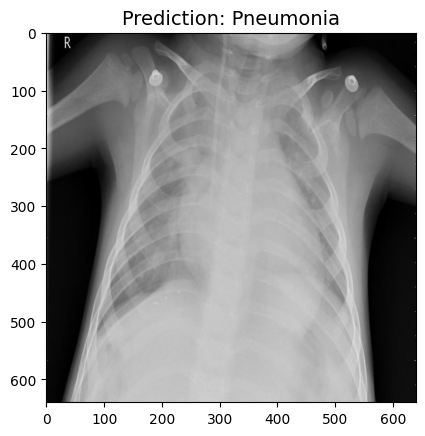

In [22]:
prediction = model.predict(img) >= 0.5
if prediction>=0.5:
  prediction = "Pneumonia"
else:
  prediction = "Normal"
print("Prediction: "+prediction)
plt.imshow(tempimg)
plt.title("Prediction: "+prediction, fontsize=14)

In [23]:
img= cv2.imread(r"C:\Users\manya\OneDrive\Desktop\PneumoniaDetection\dataset\test\NORMAL\NORMAL2-IM-1156-0001_jpeg.rf.b79840742500b7bbec2809b9077e0551.jpg")
tempimg = img
img = cv2.resize(img,(300,300))
img = img/255.0
img = img.reshape(1,300,300,3)
model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([[0.00114326]], dtype=float32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Prediction: Normal


Text(0.5, 1.0, 'Prediction: Normal')

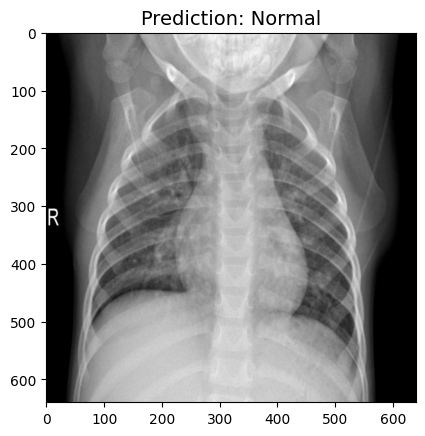

In [24]:
prediction = model.predict(img) >= 0.5
if prediction>=0.5:
  prediction = "Pneumonia"
else:
  prediction = "Normal"
print("Prediction: "+prediction)
plt.imshow(tempimg)
plt.title("Prediction: "+prediction, fontsize=14)

## Conclusion :
This model can be used in Healthcare industry in the radiological department.

It can be deployed to Xray machines.

This can help radiologist to predict the chest xray images easily and accurately.